# Nowcasting espaço-temporal de inundações urbanas com uma mini U-RNN

Este notebook implementa uma versão didática e reduzida de nowcasting de inundações urbanas inspirada no artigo **U-RNN high-resolution spatiotemporal nowcasting of urban flooding** e no repositório oficial `holmescao/U-RNN`.

A proposta não é reproduzir integralmente o treinamento do artigo, porque o trabalho original utiliza grades de alta resolução, sequências temporais longas, dados hidrodinâmicos gerados por simulador e treinamento com GPU. Como este projeto deve rodar em CPU e com baixo custo computacional, foi construída uma versão simplificada com dados sintéticos controlados.

Mesmo sendo reduzida, a implementação preserva a lógica central do U-RNN: entradas de chuva e terreno, estado recorrente convolucional, estrutura encoder-decoder com conexão de salto, cabeça de classificação de área molhada e cabeça de regressão de profundidade.

Ao final, o notebook gera evidências verificáveis em `outputs/`: figuras, animação em GIF, métricas numéricas e logs de execução.

## Relação com o artigo e com o repositório oficial

Esta seção resume quais partes da metodologia original foram aproveitadas e quais foram simplificadas para permitir execução em CPU.

Conceitos aproveitados do artigo:

- **Nowcasting**: predição de curto prazo da evolução espacial e temporal da inundação.
- **Entradas externas**: chuva instantânea, chuva acumulada e informações espaciais do terreno urbano.
- **Informações espaciais**: elevação/DSM, impermeabilidade e drenagem, representadas aqui por camadas sintéticas.
- **Arquitetura U-like recorrente**: encoder-decoder convolucional com estado temporal, inspirado no formato geral do U-RNN.
- **ConvGRU/Skip-ConvGRU**: uso de estado oculto com operações convolucionais para capturar dinâmica espaço-temporal.
- **Cabeças desacopladas**: uma saída para profundidade de inundação e outra para classificação de célula molhada/seca.
- **SWP**: ideia de trabalhar com janelas temporais para reduzir custo de memória em sequências longas. Neste notebook, a lógica é discutida, mas não reproduzida integralmente.

Diferenças desta implementação:

- usa grade pequena (`32 x 32`) para rodar em CPU;
- usa dados sintéticos, não o UrbanFlood24 completo;
- treina por poucas épocas apenas para demonstrar o pipeline;
- não substitui validação hidrodinâmica real com MIKE+, sensores, topografia real ou dados locais;
- deve ser interpretada como protótipo didático, não como sistema operacional de alerta.

In [1]:
# Esta celula verifica se as dependencias minimas estao instaladas.
# O notebook foi planejado para CPU, mas usa PyTorch para representar a mini U-RNN.
# Se alguma biblioteca estiver ausente, instale com: pip install -r requirements.txt

import importlib.util
import os
import platform
import sys
from pathlib import Path

required_modules = ["numpy", "matplotlib", "torch", "PIL"]
missing_modules = [name for name in required_modules if importlib.util.find_spec(name) is None]

if missing_modules:
    raise ImportError(
        "Dependencias ausentes: " + ", ".join(missing_modules) +
        ". Instale as dependencias com `pip install -r requirements.txt` "
        "em um ambiente Python 3.10 a 3.12."
    )

import csv
import json
import math
import random
import time

Path(".matplotlib-cache").mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib-cache").resolve()))

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

print("Python:", sys.version.split()[0])
print("Sistema:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA disponivel:", torch.cuda.is_available())

Python: 3.12.13
Sistema: Linux-7.0.0-27-generic-x86_64-with-glibc2.43
PyTorch: 2.12.1+cpu
CUDA disponivel: False


In [2]:
# Esta celula define parametros globais pequenos para manter a execucao viavel em CPU.
# Tambem cria as pastas onde as evidencias serao salvas.

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figuras"
GIF_DIR = OUTPUT_DIR / "animacoes"
METRIC_DIR = OUTPUT_DIR / "metricas"
LOG_DIR = OUTPUT_DIR / "logs"

for path in [FIG_DIR, GIF_DIR, METRIC_DIR, LOG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
GRID_H = 32
GRID_W = 32
TIME_STEPS = 24
TRAIN_EVENTS = 10
TEST_EVENTS = 3
EPOCHS = 15
LEARNING_RATE = 0.01
WET_THRESHOLD_M = 0.03
MAX_DEPTH_M = 0.60
RAIN_MAX_MM = 45.0
CUM_RAIN_MAX_MM = 240.0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Diretorio do projeto:", PROJECT_ROOT)
print("Diretorio de saidas:", OUTPUT_DIR)
print("Dispositivo usado:", DEVICE)
print(f"Grade: {GRID_H} x {GRID_W} | Passos temporais: {TIME_STEPS} | Epocas: {EPOCHS}")

Diretorio do projeto: /home/mateus-tatsch/Documents/Americas TechGuard/Semana07/spatiotemporal_nowcasting_of_urban_flooding_u-rnn
Diretorio de saidas: /home/mateus-tatsch/Documents/Americas TechGuard/Semana07/spatiotemporal_nowcasting_of_urban_flooding_u-rnn/outputs
Dispositivo usado: cpu
Grade: 32 x 32 | Passos temporais: 24 | Epocas: 15


## Geração de dados sintéticos

O artigo utiliza dados hidrodinâmicos simulados e camadas espaciais reais, como DSM, impermeabilidade e drenagem. Neste notebook, essas entradas são representadas por dados sintéticos para permitir execução rápida em CPU, sem necessidade de baixar o dataset completo.

Cada evento sintético contém:

- uma série temporal de chuva;
- uma chuva acumulada derivada;
- uma grade de elevação normalizada;
- uma grade de impermeabilidade;
- uma grade de drenagem;
- uma sequência de profundidade de inundação usada como referência didática.

A referência de inundação é gerada por uma regra simplificada de acumulação, drenagem e difusão espacial. Ela serve para testar o pipeline de aprendizado de máquina, mas não deve ser interpretada como uma simulação hidrodinâmica real.

In [3]:
# Esta celula define funcoes para gerar dados sinteticos.
# A referencia de inundacao e produzida por uma regra simplificada de acumulacao,
# drenagem e difusao espacial. Ela nao e um solver hidrodinamico real.

def minmax_scale(array, eps=1e-8):
    """Normaliza um array para o intervalo [0, 1]."""
    array = np.asarray(array, dtype=np.float32)
    return (array - array.min()) / (array.max() - array.min() + eps)


def smooth2d(array, rounds=2):
    """Aplica uma suavizacao simples por vizinhanca usando deslocamentos de grade."""
    smoothed = array.astype(np.float32).copy()
    for _ in range(rounds):
        smoothed = (
            smoothed
            + np.roll(smoothed, 1, axis=0)
            + np.roll(smoothed, -1, axis=0)
            + np.roll(smoothed, 1, axis=1)
            + np.roll(smoothed, -1, axis=1)
        ) / 5.0
    return smoothed


def make_spatial_fields(height, width, rng):
    """Cria elevacao, impermeabilidade e drenagem sinteticas."""
    y, x = np.mgrid[0:height, 0:width]
    x_norm = x / max(width - 1, 1)
    y_norm = y / max(height - 1, 1)

    slope = 0.55 * x_norm + 0.25 * y_norm
    depression_1 = -0.35 * np.exp(-((x_norm - 0.35) ** 2 + (y_norm - 0.70) ** 2) / 0.020)
    depression_2 = -0.22 * np.exp(-((x_norm - 0.72) ** 2 + (y_norm - 0.38) ** 2) / 0.030)
    roughness = smooth2d(rng.normal(0.0, 0.035, size=(height, width)), rounds=4)
    elevation = minmax_scale(slope + depression_1 + depression_2 + roughness)

    road_horizontal = np.exp(-((y_norm - 0.55) ** 2) / 0.0025)
    road_vertical = np.exp(-((x_norm - 0.48) ** 2) / 0.0020)
    built_blocks = smooth2d((rng.random((height, width)) > 0.62).astype(np.float32), rounds=2)
    impervious = np.clip(0.25 + 0.45 * built_blocks + 0.35 * road_horizontal + 0.35 * road_vertical, 0.0, 1.0)

    drainage = np.zeros((height, width), dtype=np.float32)
    candidate_mask = (road_horizontal + road_vertical > 0.55) & (elevation < 0.72)
    drainage[candidate_mask & (rng.random((height, width)) > 0.86)] = 1.0
    drainage = smooth2d(drainage, rounds=1)
    drainage = np.clip(drainage, 0.0, 1.0)

    return {
        "elevation": elevation.astype(np.float32),
        "impervious": impervious.astype(np.float32),
        "drainage": drainage.astype(np.float32),
    }


def make_rain_event(time_steps, rng):
    """Gera uma chuva temporal com pico principal e pico secundario."""
    t = np.arange(time_steps, dtype=np.float32)
    peak = rng.uniform(0.35, 0.70) * time_steps
    width = rng.uniform(2.8, 5.2)
    intensity = rng.uniform(22.0, 42.0)
    secondary_peak = rng.uniform(0.10, 0.90) * time_steps
    secondary_intensity = rng.uniform(4.0, 11.0)

    rain = intensity * np.exp(-0.5 * ((t - peak) / width) ** 2)
    rain += secondary_intensity * np.exp(-0.5 * ((t - secondary_peak) / 2.4) ** 2)
    rain += rng.uniform(0.0, 1.2, size=time_steps)
    return rain.astype(np.float32)


def simulate_reference_flood(rainfall_mm, spatial_fields):
    """Simula uma referencia sintetica de profundidade de inundacao em metros."""
    elevation = spatial_fields["elevation"]
    impervious = spatial_fields["impervious"]
    drainage = spatial_fields["drainage"]
    low_area = 1.0 - elevation

    height, width = elevation.shape
    water = np.zeros((height, width), dtype=np.float32)
    sequence = []

    for rain_mm in rainfall_mm:
        rain_m = rain_mm / 1000.0
        runoff = rain_m * (0.22 + 0.88 * impervious) * (0.55 + 0.75 * low_area)

        neighbor_mean = (
            np.roll(water, 1, axis=0)
            + np.roll(water, -1, axis=0)
            + np.roll(water, 1, axis=1)
            + np.roll(water, -1, axis=1)
        ) / 4.0

        diffusion = 0.18 * (neighbor_mean - water)
        retention = 0.82 + 0.16 * low_area
        drain_loss = water * (0.025 + 0.32 * drainage)

        water = water * retention + runoff + diffusion - drain_loss
        water = np.clip(water, 0.0, MAX_DEPTH_M)
        sequence.append(water.astype(np.float32).copy())

    return np.stack(sequence, axis=0)


def build_synthetic_dataset(train_events, test_events, height, width, time_steps, seed):
    """Cria eventos de treino e teste com a mesma geografia sintetica."""
    rng = np.random.default_rng(seed)
    spatial_fields = make_spatial_fields(height, width, rng)
    all_events = []

    for event_id in range(train_events + test_events):
        rainfall = make_rain_event(time_steps, rng)
        flood = simulate_reference_flood(rainfall, spatial_fields)
        all_events.append({
            "event_id": f"event_{event_id:02d}",
            "rainfall": rainfall,
            "flood": flood,
        })

    return spatial_fields, all_events[:train_events], all_events[train_events:]

In [4]:
# Esta celula cria o dataset sintetico e mostra os formatos.
# Os formatos seguem a ideia do repositorio oficial: flood em (T, H, W) e rainfall em (T,).

spatial_fields, train_data, test_data = build_synthetic_dataset(
    train_events=TRAIN_EVENTS,
    test_events=TEST_EVENTS,
    height=GRID_H,
    width=GRID_W,
    time_steps=TIME_STEPS,
    seed=SEED,
)

example_event = train_data[0]

print("Eventos de treino:", len(train_data))
print("Eventos de teste:", len(test_data))
print("rainfall shape:", example_event["rainfall"].shape)
print("flood shape:", example_event["flood"].shape)
print("elevation shape:", spatial_fields["elevation"].shape)

Eventos de treino: 10
Eventos de teste: 3
rainfall shape: (24,)
flood shape: (24, 32, 32)
elevation shape: (32, 32)


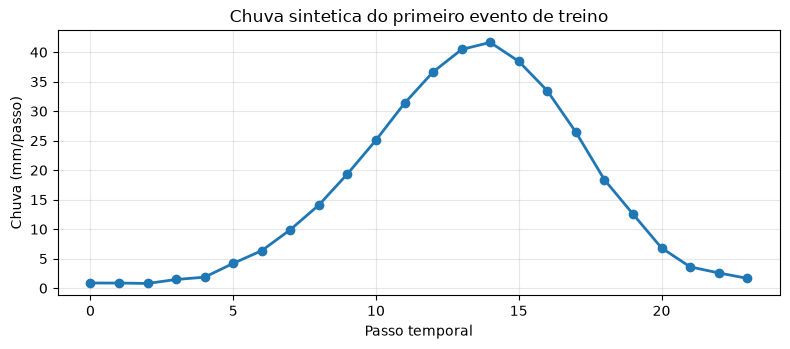

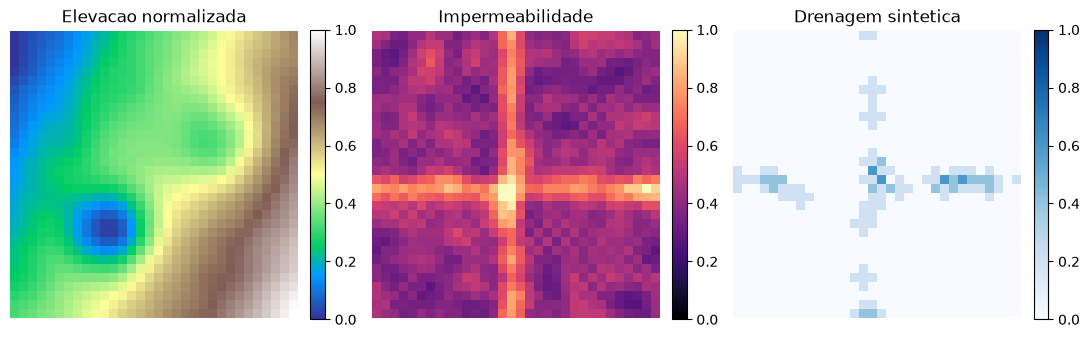

Figura salva: /home/mateus-tatsch/Documents/Americas TechGuard/Semana07/spatiotemporal_nowcasting_of_urban_flooding_u-rnn/outputs/figuras/entrada_chuva.png
Figura salva: /home/mateus-tatsch/Documents/Americas TechGuard/Semana07/spatiotemporal_nowcasting_of_urban_flooding_u-rnn/outputs/figuras/variaveis_espaciais.png


In [5]:
# Esta celula visualiza as entradas principais usadas pelo modelo.
# Ela salva duas evidencias: a chuva temporal e as camadas espaciais sinteticas.

rain_path = FIG_DIR / "entrada_chuva.png"
spatial_path = FIG_DIR / "variaveis_espaciais.png"

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(example_event["rainfall"], marker="o", linewidth=2)
ax.set_title("Chuva sintetica do primeiro evento de treino")
ax.set_xlabel("Passo temporal")
ax.set_ylabel("Chuva (mm/passo)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(rain_path, dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
layers = [
    ("Elevacao normalizada", spatial_fields["elevation"], "terrain"),
    ("Impermeabilidade", spatial_fields["impervious"], "magma"),
    ("Drenagem sintetica", spatial_fields["drainage"], "Blues"),
]

for axis, (title, layer, cmap) in zip(axes, layers):
    image = axis.imshow(layer, cmap=cmap, vmin=0, vmax=1)
    axis.set_title(title)
    axis.axis("off")
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(spatial_path, dpi=150)
plt.show()

print("Figura salva:", rain_path)
print("Figura salva:", spatial_path)

## Mini U-RNN em PyTorch

A arquitetura abaixo é reduzida, mas preserva a lógica central usada pelo U-RNN: processar mapas espaciais ao longo do tempo e manter um estado recorrente que representa a evolução da inundação.

Componentes principais desta mini U-RNN:

- entrada com chuva atual, chuva acumulada, elevação, impermeabilidade, drenagem e profundidade anterior;
- encoder convolucional em resolução original;
- camada profunda em meia resolução;
- células ConvGRU para manter estado temporal;
- upsampling e skip connection no estilo U-like;
- cabeça de profundidade e cabeça de classificação molhado/seco.

Durante o treino, usamos **teacher forcing**: a profundidade anterior vem da referência sintética. Durante a inferência, o modelo usa sua própria predição anterior como entrada do próximo passo temporal. Esse comportamento simula o nowcasting autoregressivo, no qual a previsão evolui passo a passo no tempo.

In [6]:
# Esta celula implementa a celula ConvGRU e a mini arquitetura U-like.
# Ela e propositalmente pequena para rodar em CPU e servir como demonstracao didatica.

class ConvGRUCell(nn.Module):
    """Celula ConvGRU simples com gates calculados por convolucoes 2D."""

    def __init__(self, input_channels, hidden_channels, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.hidden_channels = hidden_channels
        self.gates = nn.Conv2d(input_channels + hidden_channels, 2 * hidden_channels, kernel_size, padding=padding)
        self.candidate = nn.Conv2d(input_channels + hidden_channels, hidden_channels, kernel_size, padding=padding)

    def forward(self, x, h_prev=None):
        if h_prev is None:
            h_prev = torch.zeros(
                x.shape[0], self.hidden_channels, x.shape[2], x.shape[3],
                device=x.device, dtype=x.dtype,
            )

        gate_input = torch.cat([x, h_prev], dim=1)
        reset_gate, update_gate = torch.chunk(torch.sigmoid(self.gates(gate_input)), chunks=2, dim=1)
        candidate_input = torch.cat([x, reset_gate * h_prev], dim=1)
        candidate_state = torch.tanh(self.candidate(candidate_input))
        h_new = (1.0 - update_gate) * h_prev + update_gate * candidate_state
        return h_new


class MiniURNN(nn.Module):
    """Mini rede U-like recorrente inspirada no U-RNN."""

    def __init__(self, input_channels=6, hidden_full=8, hidden_deep=12, max_depth=0.60):
        super().__init__()
        self.max_depth = max_depth
        self.input_projection = nn.Conv2d(input_channels, hidden_full, kernel_size=3, padding=1)
        self.full_gru = ConvGRUCell(hidden_full, hidden_full)
        self.downsample = nn.Conv2d(hidden_full, hidden_deep, kernel_size=3, stride=2, padding=1)
        self.deep_gru = ConvGRUCell(hidden_deep, hidden_deep)
        self.upsample = nn.ConvTranspose2d(hidden_deep, hidden_full, kernel_size=2, stride=2)
        self.fuse = nn.Conv2d(hidden_full * 2, hidden_full, kernel_size=3, padding=1)
        self.depth_head = nn.Conv2d(hidden_full, 1, kernel_size=1)
        self.wet_head = nn.Conv2d(hidden_full, 1, kernel_size=1)

    def forward_step(self, x, state):
        h_full, h_deep = state

        encoded = F.relu(self.input_projection(x))
        h_full = self.full_gru(encoded, h_full)

        deep_input = F.relu(self.downsample(h_full))
        h_deep = self.deep_gru(deep_input, h_deep)

        decoded = F.relu(self.upsample(h_deep))
        decoded = decoded[:, :, :h_full.shape[2], :h_full.shape[3]]
        fused = F.relu(self.fuse(torch.cat([decoded, h_full], dim=1)))

        depth = torch.sigmoid(self.depth_head(fused)) * self.max_depth
        wet_logits = self.wet_head(fused)
        return depth, wet_logits, (h_full, h_deep)


def make_static_tensor(spatial_fields, device):
    """Converte as camadas espaciais para tensor PyTorch com shape (1, 3, H, W)."""
    static = np.stack([
        spatial_fields["elevation"],
        spatial_fields["impervious"],
        spatial_fields["drainage"],
    ], axis=0)
    return torch.tensor(static, dtype=torch.float32, device=device).unsqueeze(0)


def run_sequence(model, static_tensor, rainfall_mm, target_sequence=None, teacher_forcing=False):
    """Executa a rede passo a passo, preservando o estado recorrente."""
    rainfall = torch.tensor(rainfall_mm, dtype=torch.float32, device=static_tensor.device)
    cumulative = torch.cumsum(rainfall, dim=0)

    batch, _, height, width = static_tensor.shape
    previous_depth = torch.zeros(batch, 1, height, width, device=static_tensor.device)
    state = (None, None)

    predictions = []
    wet_logits_list = []

    for step in range(rainfall.shape[0]):
        rain_grid = torch.full((batch, 1, height, width), rainfall[step] / RAIN_MAX_MM, device=static_tensor.device)
        cumsum_grid = torch.full((batch, 1, height, width), cumulative[step] / CUM_RAIN_MAX_MM, device=static_tensor.device)
        model_input = torch.cat([rain_grid, cumsum_grid, static_tensor, previous_depth / MAX_DEPTH_M], dim=1)

        predicted_depth, wet_logits, state = model.forward_step(model_input, state)
        predictions.append(predicted_depth)
        wet_logits_list.append(wet_logits)

        if teacher_forcing and target_sequence is not None:
            previous_depth = target_sequence[:, step:step + 1]
        else:
            previous_depth = predicted_depth.detach()

    return torch.cat(predictions, dim=1), torch.cat(wet_logits_list, dim=1)


static_tensor = make_static_tensor(spatial_fields, DEVICE)
model = MiniURNN(input_channels=6, hidden_full=8, hidden_deep=12, max_depth=MAX_DEPTH_M).to(DEVICE)
total_params = sum(parameter.numel() for parameter in model.parameters())

print(model)
print(f"Parametros treinaveis: {total_params:,}")

MiniURNN(
  (input_projection): Conv2d(6, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (full_gru): ConvGRUCell(
    (gates): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (candidate): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (downsample): Conv2d(8, 12, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (deep_gru): ConvGRUCell(
    (gates): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (candidate): Conv2d(24, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (upsample): ConvTranspose2d(12, 8, kernel_size=(2, 2), stride=(2, 2))
  (fuse): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (depth_head): Conv2d(8, 1, kernel_size=(1, 1), stride=(1, 1))
  (wet_head): Conv2d(8, 1, kernel_size=(1, 1), stride=(1, 1))
)
Parametros treinaveis: 14,178


## Treinamento em CPU

Nesta etapa, a mini U-RNN aprende a aproximar a sequência sintética de inundação. O treinamento é propositalmente curto para manter o notebook executável em CPU.

A função de perda combina dois objetivos:

- **erro de profundidade**: compara a profundidade prevista com a referência sintética;
- **erro de área molhada/seca**: ajuda o modelo a distinguir células inundadas e não inundadas.

Essa escolha segue a ideia do artigo de separar regressão de profundidade e classificação de inundação, ainda que em uma arquitetura muito menor.


In [7]:
# Esta celula treina a mini U-RNN por poucas epocas.
# A perda combina regressao de profundidade com classificacao de celula molhada/seca,
# refletindo a ideia das cabecas desacopladas descritas no artigo.

def event_target_tensor(event, device):
    """Converte flood.npy sintetico, shape (T, H, W), para tensor (1, T, H, W)."""
    return torch.tensor(event["flood"], dtype=torch.float32, device=device).unsqueeze(0)


optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = []
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    random.shuffle(train_data)
    train_losses = []

    for event in train_data:
        target = event_target_tensor(event, DEVICE)
        wet_target = (target > WET_THRESHOLD_M).float()

        optimizer.zero_grad()
        predicted, wet_logits = run_sequence(
            model,
            static_tensor,
            event["rainfall"],
            target_sequence=target,
            teacher_forcing=True,
        )

        depth_loss = F.mse_loss(predicted, target)
        wet_loss = F.binary_cross_entropy_with_logits(wet_logits, wet_target)
        loss = depth_loss + 0.02 * wet_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(float(loss.detach().cpu()))

    model.eval()
    val_losses = []
    with torch.no_grad():
        for event in test_data:
            target = event_target_tensor(event, DEVICE)
            predicted, wet_logits = run_sequence(model, static_tensor, event["rainfall"], teacher_forcing=False)
            val_losses.append(float(F.mse_loss(predicted, target).detach().cpu()))

    epoch_record = {
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "val_mse": float(np.mean(val_losses)),
    }
    history.append(epoch_record)
    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={epoch_record['train_loss']:.6f} | val_mse={epoch_record['val_mse']:.6f}")

elapsed = time.time() - start_time
print(f"Treinamento concluido em {elapsed:.1f} segundos no dispositivo {DEVICE}.")

Epoch 01/15 | train_loss=0.048499 | val_mse=0.009315


Epoch 02/15 | train_loss=0.018588 | val_mse=0.010527


Epoch 03/15 | train_loss=0.018315 | val_mse=0.008330


Epoch 04/15 | train_loss=0.016339 | val_mse=0.004303


Epoch 05/15 | train_loss=0.014980 | val_mse=0.002096


...

Epoch 11/15 | train_loss=0.004853 | val_mse=0.002388


Epoch 12/15 | train_loss=0.004528 | val_mse=0.002665


Epoch 13/15 | train_loss=0.004376 | val_mse=0.002657


Epoch 14/15 | train_loss=0.003666 | val_mse=0.002299


Epoch 15/15 | train_loss=0.003133 | val_mse=0.002207
Treinamento concluido em 9.0 segundos no dispositivo cpu.


## Inferência autoregressiva

Depois do treinamento, o modelo é avaliado em um evento de teste que não foi usado para ajustar os pesos.

Na inferência, a rede não recebe mais a profundidade real do passo anterior. Ela usa a própria predição como entrada do próximo instante. Esse detalhe é importante porque aproxima o comportamento de nowcasting: a previsão precisa evoluir no tempo usando os estados previstos pelo próprio modelo.


In [8]:
# Esta celula executa nowcasting autoregressivo em um evento de teste.
# Na inferencia, o modelo usa a propria profundidade prevista como entrada do passo seguinte.

model.eval()
selected_event = test_data[0]

with torch.no_grad():
    predicted_tensor, wet_logits_tensor = run_sequence(
        model,
        static_tensor,
        selected_event["rainfall"],
        teacher_forcing=False,
    )

prediction = predicted_tensor.squeeze(0).detach().cpu().numpy()
reference = selected_event["flood"]
absolute_error = np.abs(prediction - reference)

print("Evento avaliado:", selected_event["event_id"])
print("Predicao shape:", prediction.shape)
print("Referencia shape:", reference.shape)
print("Profundidade prevista maxima (m):", float(prediction.max()))
print("Profundidade de referencia maxima (m):", float(reference.max()))

Evento avaliado: event_10
Predicao shape: (24, 32, 32)
Referencia shape: (24, 32, 32)
Profundidade prevista maxima (m): 0.16338658332824707
Profundidade de referencia maxima (m): 0.25208014249801636


## Métricas de avaliação

As métricas abaixo ajudam a avaliar dois aspectos diferentes da previsão:

- **MAE**: erro absoluto médio da profundidade da água, em metros;
- **RMSE**: penaliza mais os erros maiores de profundidade;
- **CSI**: mede o acerto da extensão inundada, considerando uma célula como alagada quando a profundidade passa do limiar definido.

Essa separação é útil porque um modelo pode acertar bem a área inundada e, ainda assim, subestimar ou superestimar a profundidade da água.


In [9]:
# Esta celula calcula metricas objetivas para a sequencia temporal.
# MAE e RMSE avaliam profundidade; CSI avalia extensao inundada usando um limiar.

def compute_temporal_metrics(prediction, reference, wet_threshold):
    """Calcula MAE, RMSE, CSI e areas inundadas por passo temporal."""
    mae = np.mean(np.abs(prediction - reference), axis=(1, 2))
    rmse = np.sqrt(np.mean((prediction - reference) ** 2, axis=(1, 2)))

    pred_wet = prediction > wet_threshold
    ref_wet = reference > wet_threshold
    hits = np.logical_and(pred_wet, ref_wet).sum(axis=(1, 2))
    false_alarms = np.logical_and(pred_wet, ~ref_wet).sum(axis=(1, 2))
    misses = np.logical_and(~pred_wet, ref_wet).sum(axis=(1, 2))
    csi = hits / np.maximum(hits + false_alarms + misses, 1)

    pred_area = pred_wet.sum(axis=(1, 2))
    ref_area = ref_wet.sum(axis=(1, 2))

    return {
        "mae": mae,
        "rmse": rmse,
        "csi": csi,
        "pred_area": pred_area,
        "ref_area": ref_area,
    }


metrics = compute_temporal_metrics(prediction, reference, WET_THRESHOLD_M)

summary = {
    "event_id": selected_event["event_id"],
    "mae_mean_m": float(metrics["mae"].mean()),
    "rmse_mean_m": float(metrics["rmse"].mean()),
    "csi_mean": float(metrics["csi"].mean()),
    "max_reference_depth_m": float(reference.max()),
    "max_prediction_depth_m": float(prediction.max()),
}

print(json.dumps(summary, indent=2))

{
  "event_id": "event_10",
  "mae_mean_m": 0.02975655160844326,
  "rmse_mean_m": 0.03726637363433838,
  "csi_mean": 0.8448036192638811,
  "max_reference_depth_m": 0.25208014249801636,
  "max_prediction_depth_m": 0.16338658332824707
}


## Visualização das previsões

As figuras seguintes transformam os tensores previstos em evidências visuais. A comparação usa três linhas: referência sintética, predição da mini U-RNN e erro absoluto. Esse formato segue a lógica das visualizações do repositório oficial, facilitando a auditoria do resultado.


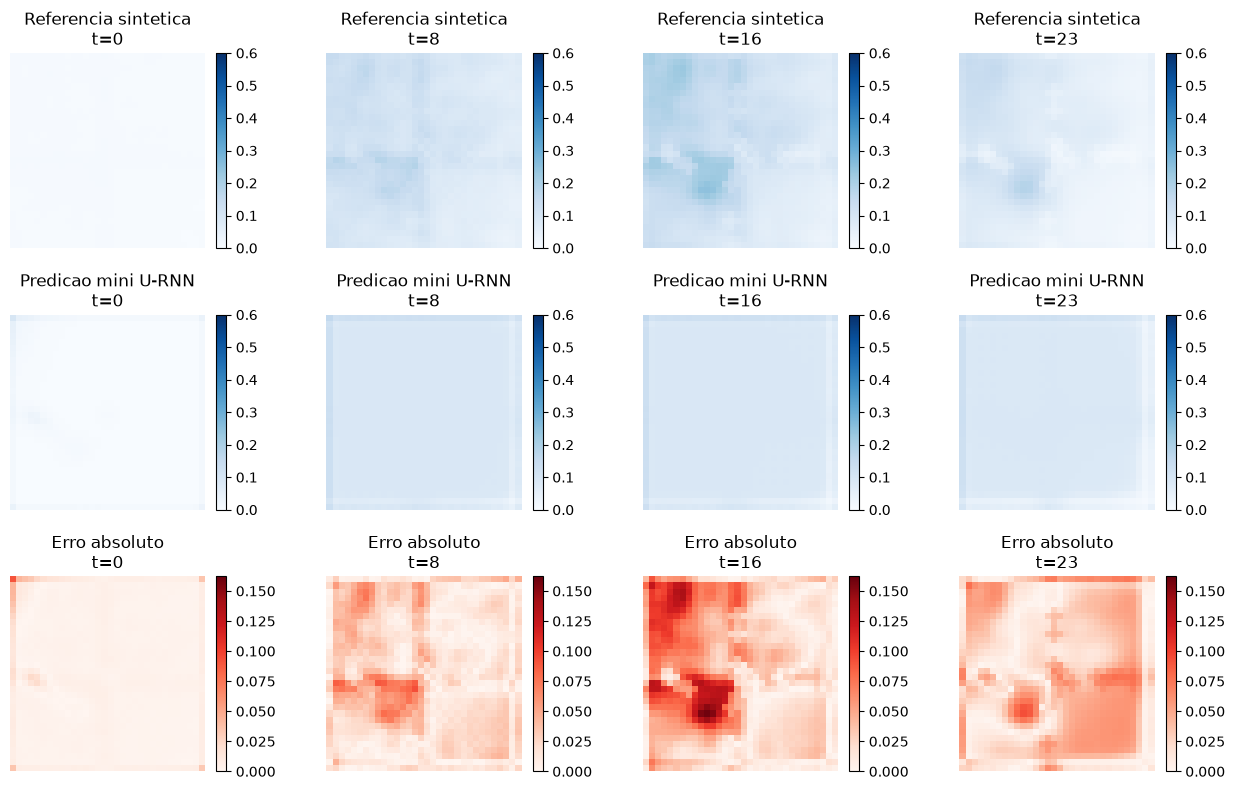

Figura salva: /home/mateus-tatsch/Documents/Americas TechGuard/Semana07/spatiotemporal_nowcasting_of_urban_flooding_u-rnn/outputs/figuras/comparacao_predicao_referencia.png


In [10]:
# Esta celula cria uma figura comparando referencia, predicao e erro absoluto.
# Ela imita a ideia de visualizacao do repositorio oficial: linhas para referencia,
# modelo e erro, com varios tempos da sequencia.

comparison_path = FIG_DIR / "comparacao_predicao_referencia.png"
time_points = [0, TIME_STEPS // 3, 2 * TIME_STEPS // 3, TIME_STEPS - 1]

fig, axes = plt.subplots(3, len(time_points), figsize=(13, 8))
rows = [
    ("Referencia sintetica", reference, "Blues", 0.0, MAX_DEPTH_M),
    ("Predicao mini U-RNN", prediction, "Blues", 0.0, MAX_DEPTH_M),
    ("Erro absoluto", absolute_error, "Reds", 0.0, max(0.12, float(absolute_error.max()))),
]

for row_index, (row_title, sequence, cmap, vmin, vmax) in enumerate(rows):
    for col_index, step in enumerate(time_points):
        axis = axes[row_index, col_index]
        image = axis.imshow(sequence[step], cmap=cmap, vmin=vmin, vmax=vmax)
        axis.set_title(f"{row_title}\nt={step}")
        axis.axis("off")
        fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(comparison_path, dpi=150)
plt.show()

print("Figura salva:", comparison_path)

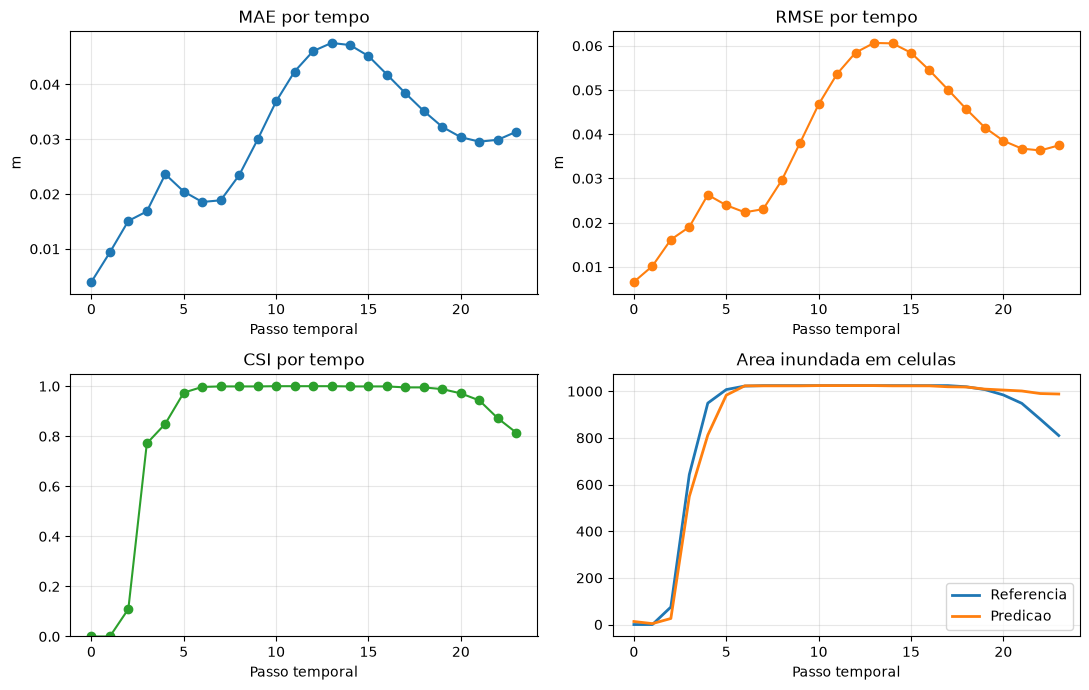

Figura salva: /home/mateus-tatsch/Documents/Americas TechGuard/Semana07/spatiotemporal_nowcasting_of_urban_flooding_u-rnn/outputs/figuras/metricas_temporais.png


In [11]:
# Esta celula plota as metricas ao longo do tempo.
# Isso ajuda a verificar se a qualidade muda durante a evolucao da chuva e da inundacao.

metrics_path = FIG_DIR / "metricas_temporais.png"
steps = np.arange(TIME_STEPS)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].plot(steps, metrics["mae"], marker="o")
axes[0, 0].set_title("MAE por tempo")
axes[0, 0].set_ylabel("m")

axes[0, 1].plot(steps, metrics["rmse"], marker="o", color="tab:orange")
axes[0, 1].set_title("RMSE por tempo")
axes[0, 1].set_ylabel("m")

axes[1, 0].plot(steps, metrics["csi"], marker="o", color="tab:green")
axes[1, 0].set_title("CSI por tempo")
axes[1, 0].set_ylim(0, 1.05)

axes[1, 1].plot(steps, metrics["ref_area"], label="Referencia", linewidth=2)
axes[1, 1].plot(steps, metrics["pred_area"], label="Predicao", linewidth=2)
axes[1, 1].set_title("Area inundada em celulas")
axes[1, 1].legend()

for axis in axes.ravel():
    axis.set_xlabel("Passo temporal")
    axis.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(metrics_path, dpi=150)
plt.show()

print("Figura salva:", metrics_path)

In [12]:
# Esta celula cria um GIF da profundidade prevista ao longo do tempo.
# O GIF e uma evidencia visual direta de nowcasting, pois mostra a evolucao temporal.

gif_path = GIF_DIR / "nowcasting.gif"

def depth_to_rgb_frame(depth, max_depth, scale=8):
    """Converte uma matriz de profundidade em imagem RGB usando colormap."""
    normalized = np.clip(depth / max_depth, 0.0, 1.0)
    rgba = plt.cm.Blues(normalized)
    rgb = (rgba[:, :, :3] * 255).astype(np.uint8)
    image = Image.fromarray(rgb)
    return image.resize((depth.shape[1] * scale, depth.shape[0] * scale), Image.Resampling.NEAREST)


frames = [depth_to_rgb_frame(prediction[step], MAX_DEPTH_M) for step in range(TIME_STEPS)]
frames[0].save(
    gif_path,
    save_all=True,
    append_images=frames[1:],
    duration=180,
    loop=0,
)

print("GIF salvo:", gif_path)

GIF salvo: /home/mateus-tatsch/Documents/Americas TechGuard/Semana07/spatiotemporal_nowcasting_of_urban_flooding_u-rnn/outputs/animacoes/nowcasting.gif


## Registro das evidências

Além de mostrar os gráficos no notebook, esta etapa salva os resultados em arquivos. Isso é importante para a entrega da atividade, porque permite verificar o funcionamento sem depender apenas da visualização das células executadas.

Os arquivos gerados ficam em `outputs/figuras`, `outputs/animacoes`, `outputs/metricas` e `outputs/logs`.


In [13]:
# Esta celula salva metricas e log de execucao em arquivos.
# Esses arquivos ajudam na auditoria da entrega pelo avaliador.

metrics_csv_path = METRIC_DIR / "metricas.csv"
history_csv_path = METRIC_DIR / "historico_treinamento.csv"
summary_json_path = LOG_DIR / "resumo_execucao.json"

with metrics_csv_path.open("w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["time_step", "mae_m", "rmse_m", "csi", "ref_area_cells", "pred_area_cells"])
    for step in range(TIME_STEPS):
        writer.writerow([
            step,
            float(metrics["mae"][step]),
            float(metrics["rmse"][step]),
            float(metrics["csi"][step]),
            int(metrics["ref_area"][step]),
            int(metrics["pred_area"][step]),
        ])

with history_csv_path.open("w", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=["epoch", "train_loss", "val_mse"])
    writer.writeheader()
    writer.writerows(history)

execution_summary = {
    "device": str(DEVICE),
    "grid": [GRID_H, GRID_W],
    "time_steps": TIME_STEPS,
    "train_events": TRAIN_EVENTS,
    "test_events": TEST_EVENTS,
    "epochs": EPOCHS,
    "summary_metrics": summary,
    "outputs": {
        "rainfall": str(rain_path),
        "spatial_fields": str(spatial_path),
        "comparison": str(comparison_path),
        "temporal_metrics": str(metrics_path),
        "gif": str(gif_path),
        "metrics_csv": str(metrics_csv_path),
        "training_history_csv": str(history_csv_path),
    },
}

with summary_json_path.open("w") as file:
    json.dump(execution_summary, file, indent=2)

print("Metricas salvas:", metrics_csv_path)
print("Historico salvo:", history_csv_path)
print("Resumo salvo:", summary_json_path)

Metricas salvas: /home/mateus-tatsch/Documents/Americas TechGuard/Semana07/spatiotemporal_nowcasting_of_urban_flooding_u-rnn/outputs/metricas/metricas.csv
Historico salvo: /home/mateus-tatsch/Documents/Americas TechGuard/Semana07/spatiotemporal_nowcasting_of_urban_flooding_u-rnn/outputs/metricas/historico_treinamento.csv
Resumo salvo: /home/mateus-tatsch/Documents/Americas TechGuard/Semana07/spatiotemporal_nowcasting_of_urban_flooding_u-rnn/outputs/logs/resumo_execucao.json


## Seção opcional: aproximação ao quickstart oficial

O repositório oficial possui um quickstart com três partes principais: preparação do ambiente, demonstração sintética da arquitetura e inferência real com UrbanFlood24 Lite. A inferência oficial usa pesos pré-treinados e um evento demonstrativo pequeno. Já o treinamento completo, mesmo na versão Lite, ainda é mais adequado para máquinas com GPU.

A célula abaixo fica desativada por padrão para manter a entrega reprodutível sem internet. Ela documenta uma rota de reprodução rápida baseada no material oficial. Ative somente se houver conexão disponível e tempo para baixar o repositório, os pesos pré-treinados e o evento demonstrativo.

Nesta entrega, a evidência principal continua sendo a mini U-RNN treinada e avaliada nas células anteriores. A seção oficial é complementar e serve para mostrar como este notebook se conecta ao fluxo recomendado pelo repositório `holmescao/U-RNN`.

In [14]:
# Esta celula implementa uma rota opcional baseada no quickstart oficial.
# Ela nao roda por padrao para manter o notebook reprodutivel sem internet.
# Para testar, altere RUN_OFFICIAL_LITE_INFERENCE para True.

RUN_OFFICIAL_LITE_INFERENCE = False

if RUN_OFFICIAL_LITE_INFERENCE:
    import glob
    import subprocess
    import urllib.request
    import zipfile

    external_dir = PROJECT_ROOT / "external"
    repo_dir = external_dir / "U-RNN"
    code_dir = repo_dir / "code"
    external_dir.mkdir(parents=True, exist_ok=True)

    if not repo_dir.exists():
        subprocess.run(["git", "clone", "https://github.com/holmescao/U-RNN", str(repo_dir)], check=True)

    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q",
        "pyyaml", "tqdm", "openpyxl", "seaborn", "celluloid", "opencv-python-headless"
    ], check=True)

    weights_url = "https://huggingface.co/holmescao/U-RNN/resolve/main/checkpoints/loc1_lite_weights.zip"
    demo_url = "https://huggingface.co/holmescao/U-RNN/resolve/main/demo_data/loc1_lite_demo_r100y.zip"
    weights_zip = external_dir / "loc1_lite_weights.zip"
    demo_zip = external_dir / "loc1_lite_demo_r100y.zip"

    if not weights_zip.exists():
        print("Baixando pesos Lite oficiais...")
        urllib.request.urlretrieve(weights_url, weights_zip)

    if not demo_zip.exists():
        print("Baixando evento demo Lite oficial...")
        urllib.request.urlretrieve(demo_url, demo_zip)

    with zipfile.ZipFile(weights_zip, "r") as zip_file:
        zip_file.extractall(repo_dir)

    with zipfile.ZipFile(demo_zip, "r") as zip_file:
        zip_file.extractall(repo_dir / "data")

    checkpoints = glob.glob(str(repo_dir / "exp" / "**" / "save_model" / "*.pth.tar"), recursive=True)
    if not checkpoints:
        raise FileNotFoundError("Nenhum checkpoint oficial foi encontrado apos extrair os pesos.")

    checkpoint_path = Path(checkpoints[0])
    timestamp = checkpoint_path.parts[checkpoint_path.parts.index("exp") + 1]
    test_list = external_dir / "loc1_lite_demo.txt"
    test_list.write_text("r100y_p0.5_d3h\n")

    command = [
        sys.executable, "test.py",
        "--exp_config", "configs/lite.yaml",
        "--timestamp", timestamp,
        "--data_root", "../data/urbanflood24_lite",
        "--location", "location1",
        "--test_list_file", str(test_list),
        "--device", "cpu",
    ]

    print("Rodando inferencia oficial Lite em CPU...")
    subprocess.run(command, cwd=code_dir, check=True)
    print("Resultados oficiais esperados em:", repo_dir / "exp" / timestamp / "figs")
else:
    print("Inferencia oficial Lite pulada. A implementacao principal deste notebook ja foi executada acima.")

Inferencia oficial Lite pulada. A implementacao principal deste notebook ja foi executada acima.


## Interpretação dos resultados e limitações

O notebook demonstrou um pipeline funcional de nowcasting espaço-temporal. A execução completa inclui:

- geração de chuva e camadas espaciais;
- geração de uma referência sintética de inundação;
- treinamento de uma mini rede recorrente convolucional;
- inferência autoregressiva;
- cálculo de métricas numéricas;
- geração de figuras, animação e arquivos de saída em `outputs/`.

As métricas devem ser interpretadas com cuidado. O CSI avalia principalmente a extensão inundada, enquanto MAE e RMSE avaliam erro de profundidade. Nos resultados gerados, a mini U-RNN conseguiu representar a evolução geral da área inundada, mas suavizou a distribuição espacial e subestimou alguns picos de profundidade. Isso é esperado em uma versão pequena, treinada por poucas épocas e com dados sintéticos.

Limitações técnicas:

- os dados são sintéticos e não substituem dados hidrodinâmicos reais;
- a arquitetura é reduzida e não reproduz o U-RNN completo do artigo;
- o treinamento não implementa integralmente o paradigma Sliding Window-based Pre-warming;
- a validação não usa MIKE+, sensores reais, topografia local ou rede de drenagem real;
- o resultado não deve ser apresentado como avaliação completa de risco, pois risco exige exposição, vulnerabilidade, população, infraestrutura crítica e impactos potenciais;
- a seção oficial Lite depende de internet e arquivos externos, por isso fica como complemento opcional.

Aplicação ao Americas TechGuard:

Uma versão operacional desse pipeline poderia combinar chuva observada ou prevista, sensores, satélite, geoprocessamento, dados de drenagem e dashboards para apoiar monitoramento, prevenção, resposta e emissão de alertas. Para uma prova de conceito real, seria necessário substituir os dados sintéticos por dados locais, calibrar o modelo, validar com eventos históricos e integrar o fluxo a uma infraestrutura de alerta.